In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [39]:
transform = transforms.Compose([
    tranforms.ToTensor(),
    tranforms.Normalize((0.5),(0.5))
])
train_dataset = MNIST(root ='./data',train = True,download = True,transform = transform)
test_dataset = MNIST(root ='./data',train = False,download = True,transform = transform)

In [40]:
batch_size =64
train_loader= DataLoader(train_dataset,shuffle =True, batch_size= batch_size)
test_loader= DataLoader(test_dataset,shuffle = False, batch_size= batch_size)

In [52]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()


        self.conv1= nn.Conv2d(1,16,kernel_size = 3, padding =1)
        self.relu = nn.ReLU()
        self.pool =nn.MaxPool2d(kernel_size= 2, stride = 2)

        self.conv2 = nn.Conv2d(16,32,kernel_size = 3, padding =1)

        self.fc1 = nn.Linear(32*7*7,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1,32*7*7)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = CNN()
print(cnn_model)
        
        

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [53]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN,self).__init__()

        self.input_size = 28
        self.hidden_size =128
        self.num_layers = 2
        self.num_classes = 10

        self.lstm = nn.LSTM(self.input_size,self.hidden_size,self.num_layers,batch_first= True)
        self.fc= nn.Linear(self.hidden_size, self.num_classes)

    def forward(self,x):
        x = x.squeeze(1)
        out,(hidden,cell) = self.lstm(x)
        out = self.fc(out[:,-1,:])#[Batch Size, Sequence Length, Features]
        return out 

rnn_model = RNN()
print(rnn_model)
        

RNN(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


In [54]:
criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(),lr = 0.001)
rnn_optimizer = optim.Adam(rnn_model.parameters(),lr = 0.001)

def train_model(model,optimizer,train_loader,epochs = 10):
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()
            running_loss += loss.item()

        print(f" Epoch {epoch+1}/{epochs} - Avg loss: {running_loss/len(train_loader):.4f}")

print("--- Training CNN ---")
train_model(cnn_model,cnn_optimizer,train_loader,epochs = 10 )

print("--- Training RNN ---")
train_model(rnn_model,rnn_optimizer,train_loader,epochs = 10 )
    

--- Training CNN ---
 Epoch 1/10 - Avg loss: 0.1930
 Epoch 2/10 - Avg loss: 0.0531
 Epoch 3/10 - Avg loss: 0.0390
 Epoch 4/10 - Avg loss: 0.0308
 Epoch 5/10 - Avg loss: 0.0226
 Epoch 6/10 - Avg loss: 0.0189
 Epoch 7/10 - Avg loss: 0.0159
 Epoch 8/10 - Avg loss: 0.0125
 Epoch 9/10 - Avg loss: 0.0104
 Epoch 10/10 - Avg loss: 0.0080
--- Training RNN ---
 Epoch 1/10 - Avg loss: 0.3842
 Epoch 2/10 - Avg loss: 0.0966
 Epoch 3/10 - Avg loss: 0.0665
 Epoch 4/10 - Avg loss: 0.0519
 Epoch 5/10 - Avg loss: 0.0420
 Epoch 6/10 - Avg loss: 0.0360
 Epoch 7/10 - Avg loss: 0.0292
 Epoch 8/10 - Avg loss: 0.0292
 Epoch 9/10 - Avg loss: 0.0227
 Epoch 10/10 - Avg loss: 0.0205


In [55]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

--- Evaluating CNN ---
accuracy of CNN:98.88%


--- Evaluating RNN ---
accuracy of RNN:98.82%



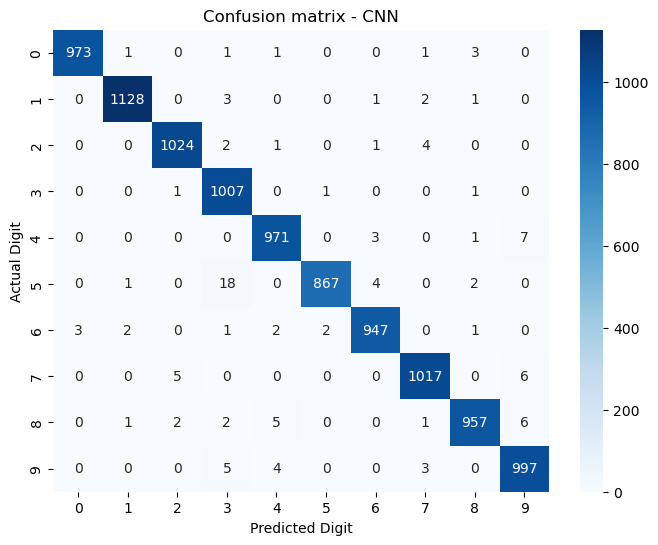

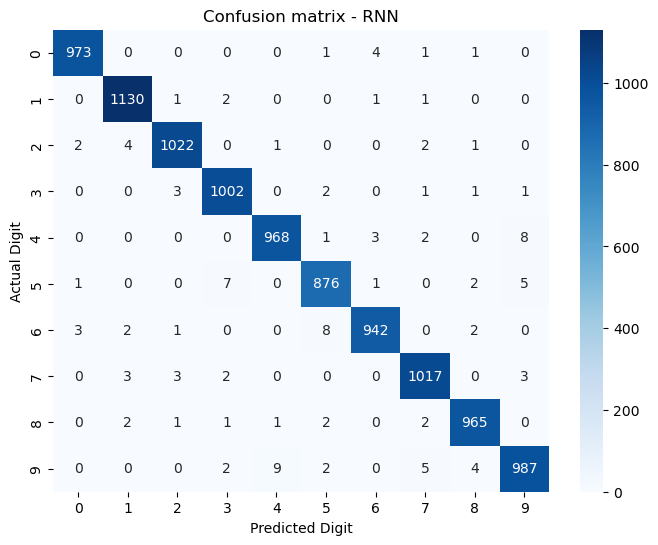

In [57]:
def evaluate_model(model,test_loader,model_name):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)

            _, predicted = torch.max(outputs.data,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())

        accuracy = 100* correct/total

        print(f"accuracy of {model_name}:{accuracy:.2f}%\n")


        cm = confusion_matrix(all_labels,all_preds)
        plt.figure(figsize=(8,6))

        sns.heatmap(cm,annot = True,fmt ='d',cmap = "Blues")
        plt.title(f"Confusion matrix - {model_name}")
        plt.xlabel("Predicted Digit")
        plt.ylabel("Actual Digit")

print("--- Evaluating CNN ---")
evaluate_model(cnn_model,test_loader,"CNN")


print("\n--- Evaluating RNN ---")
evaluate_model(rnn_model, test_loader, "RNN")
    
            
            